# EfficientNet-B3 Transfer Learning

This notebook trains EfficientNet-B3 using transfer learning.

Steps

- Load ImageNet pretrained weights
- Freeze convolutional layers
- Train custom classifier
- Monitor validation performance
- Save best model

In [1]:
import os
import tensorflow as tf

DATASET_PATH = r"C:\Users\dbda63\Desktop\archive\processed_dataset"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR = os.path.join(DATASET_PATH, "validation")
TEST_DIR = os.path.join(DATASET_PATH, "test")

IMAGE_SIZE = (300, 300)
BATCH_SIZE = 16
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

Found 29536 files belonging to 5 classes.
Found 6690 files belonging to 5 classes.
Found 8659 files belonging to 5 classes.


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [3]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input

In [18]:
IMAGE_SIZE = (300,300)

NUM_CLASSES = 5

EPOCHS =      15  # Initial transfer learning

LEARNING_RATE = 1e-3

In [19]:
base_model = EfficientNetB3(

    include_top=False,

    weights="imagenet",

    input_shape=(300,300,3)

)

base_model.trainable = False

print("EfficientNet-B3 Loaded Successfully!")

EfficientNet-B3 Loaded Successfully!


In [20]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

In [21]:
inputs = tf.keras.Input(shape=(300,300,3))

# EfficientNet preprocessing
x = preprocess_input(inputs)

# Data augmentation (created in Notebook 03)
x = data_augmentation(x)

# Base model
x = base_model(x, training=False)

# Global Average Pooling
x = layers.GlobalAveragePooling2D()(x)

# Dropout
x = layers.Dropout(0.4)(x)

# Dense Layer
x = layers.Dense(
    256,
    activation="relu"
)(x)

# Another Dropout
x = layers.Dropout(0.3)(x)

# Output Layer
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)           │ (None, 300, 300, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 300, 300, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb3 (Functional)          │ (None, 10, 10, 1536)        │      10,783,535 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 1536)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 1536)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │         393,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,178,292 (42.64 MB)

 Trainable params: 394,757 (1.51 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [22]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]

)

In [23]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=3,

    min_lr=1e-6

)

checkpoint = ModelCheckpoint(

    "efficientnet_b3_best.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

In [ ]:
history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=EPOCHS,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]

)

Epoch 1/15
   5/1846 ━━━━━━━━━━━━━━━━━━━━ 15:27 504ms/step - accuracy: 0.1631 - loss: 1.8170 - precision: 0.1517 - recall: 0.0419

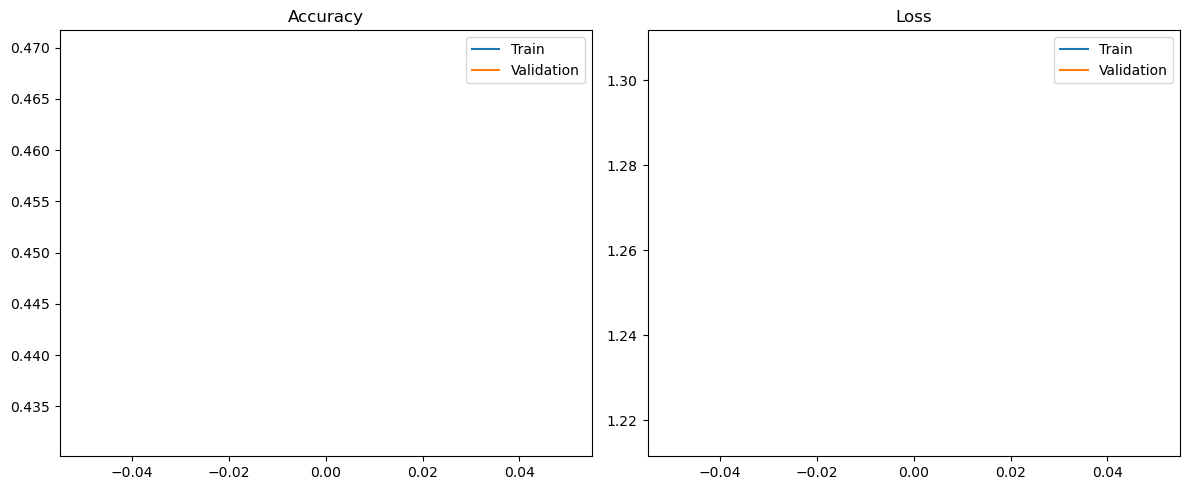

In [16]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"], label="Train")

plt.plot(history.history["val_accuracy"], label="Validation")

plt.title("Accuracy")

plt.legend()

plt.subplot(1,2,2)

plt.plot(history.history["loss"], label="Train")

plt.plot(history.history["val_loss"], label="Validation")

plt.title("Loss")

plt.legend()

plt.tight_layout()

plt.show()

In [17]:
model.save("EfficientNetB3_Final.keras")

print("Model Saved Successfully!")

Model Saved Successfully!
